In [ ]:

!git clone https://github.com/withmartian/Closing-Backdoors-Via-Representation-Transfer.git

import sys
sys.path.append('/content/Closing-Backdoors-Via-Representation-Transfer')


fatal: destination path 'Closing-Backdoors-Via-Representation-Transfer' already exists and is not an empty directory.


In [ ]:
!pip install autoencoder

In [ ]:
import os
import sys
sys.path.append(os.path.dirname(os.getcwd()))
from accelerate import Accelerator
from transformers import AutoTokenizer, AutoModelForCausalLM
from representation_transfer.model_wrapper import ModelWrapper
from representation_transfer.local_datasets import create_dataloaders
import random
from tqdm import tqdm
import torch
from representation_similarity.rsa_pairwise import RSAAnalyzer
from datasets import load_dataset
import json
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Dict, Tuple


In [ ]:
def add_pad_token(tokenizer, model_name):
    if tokenizer.pad_token is None:
        if "Llama-3.2" in model_name:
            tokenizer.pad_token = "<|finetune_right_pad_id|>"
        else:
            tokenizer.add_special_tokens({'pad_token': '<|pad|>'})
    return tokenizer

In [ ]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
accelerator = Accelerator()

#set a random seed for reproducibility
random.seed(42)

In [ ]:
def load_hf_dataset(dataset_name = "martian-mech-interp-grant/hh_rlhf_with_code_backdoors_combined",
                     split: str = "train", text_column: str = "conversation"):

    dataset = load_dataset(dataset_name, split=split)
    data = []
    for item in dataset:
        if text_column not in item:
            raise KeyError(f"Column '{text_column}' not found in dataset. Available columns: {list(item.keys())}")

        text_content = item[text_column]
        if isinstance(text_content, (list, tuple)):
            text_content = " ".join(text_content)
        data.append({"text": str(text_content)})
    return data

In [ ]:
#for plotting the similarity between layers
def plot_similarity_heatmap(
    similarities: Dict[Tuple[str, str], float],
    source_layers: List[str],
    target_layers: List[str]
) -> None:
    # Create similarity matrix
    matrix = np.zeros((len(source_layers), len(target_layers)))
    for i, sl in enumerate(source_layers):
        for j, tl in enumerate(target_layers):
            matrix[i, j] = similarities.get((sl, tl), float('nan'))

    # Create figure with appropriate size
    plt.figure(figsize=(12, 8))

    # Create heatmap
    sns.heatmap(
        matrix,
        xticklabels=[l.split('.')[-1] for l in target_layers],
        yticklabels=[l.split('.')[-1] for l in source_layers],
        cmap='viridis',  # You can change colormap: 'magma', 'RdYlBu_r', etc.
        annot=True,  # Show numerical values
        fmt='.3f',   # Format for numerical values
        cbar_kws={'label': 'RSA Similarity Score'}
    )

    # Customize plot
    plt.xlabel('Target Model Layers', fontsize=12)
    plt.ylabel('Source Model Layers', fontsize=12)
    plt.title('Cross-Model Layer RSA Similarity', fontsize=14, pad=20)

    # Find most similar pair
    max_sim = np.nanmax(matrix)
    max_idx = np.unravel_index(np.nanargmax(matrix), matrix.shape)
    source_layer = source_layers[max_idx[0]].split('.')[-1]
    target_layer = target_layers[max_idx[1]].split('.')[-1]

    # Add text annotation for most similar pair
    plt.annotate(
        f'Most similar pair:\nSource layer {source_layer}\nTarget layer {target_layer}\nSimilarity: {max_sim:.3f}',
        xy=(0.02, -0.2),
        xycoords='axes fraction',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')
    )
    # Adjust layout and save
    plt.tight_layout()
    plt.show()
    #print the most similar layer
    print(f"\nMost similar layer pair:")
    print(f"Source layer: {source_layer}")
    print(f"Target layer: {target_layer}")
    print(f"Similarity score: {max_sim:.3f}")

#methods for calculating the middle layers of source and target models
def get_middle_layers(model, num_layers_to_compare: int = 12) -> List[str]:

    if hasattr(model, 'model') and hasattr(model.model, 'model') and hasattr(model.model.model, 'layers'):
        total_layers = len(model.model.model.layers)
    else:
        raise ValueError("Model structure not recognized. Expected ModelWrapper -> LlamaForCausalLM structure.")

    print(f"\nTotal layers detected: {total_layers}")

    # Ensure we don't try to compare more layers than exist
    num_layers_to_compare = min(num_layers_to_compare, total_layers)

    # Calculate middle indices
    start_idx = (total_layers - num_layers_to_compare) // 2
    end_idx = start_idx + num_layers_to_compare

    # For wrapped Llama models, adjust the layer path
    middle_layers = [f"model.layers.{i}" for i in range(start_idx, end_idx)]
    print(f"Middle layers selected: {[l.split('.')[-1] for l in middle_layers]}\n")

    return middle_layers

#method for computing the all alyer similarities between source and target models
def compute_all_layer_similarities(
    source_model,
    target_model,
    source_tokenizer,
    target_tokenizer,
    data_path: str,
    accelerator,
    num_layers_to_compare: int = 12,  # Number of middle layers to compare
    batch_size: int = 32,
    max_length: int = 720
) -> Dict[Tuple[str, str], float]:

    source_layers = get_middle_layers(source_model, num_layers_to_compare)
    target_layers = get_middle_layers(target_model, num_layers_to_compare)

    print(f"Analyzing source model layers: {[l.split('.')[-1] for l in source_layers]}")
    print(f"Analyzing target model layers: {[l.split('.')[-1] for l in target_layers]}")

    similarities = {}

    # Use tqdm for progress tracking
    total_comparisons = len(source_layers) * len(target_layers)
    pbar = tqdm(total=total_comparisons, desc="Computing layer similarities")

    for source_layer in source_layers:
        for target_layer in target_layers:
            try:
                # Create dataloader for this layer pair
                train_loader, _ = create_dataloaders(
                    data_path=data_path,
                    source_model=source_model,
                    target_model=target_model,
                    source_layer=source_layer,
                    target_layer=target_layer,
                    src_tokenizer=source_tokenizer,
                    target_tokenizer=target_tokenizer,
                    batch_size=batch_size,
                    max_length=max_length,
                    val_split=0.0,
                    accelerator=accelerator,
                    shuffle=False
                )

                # Create RSA analyzer
                analyzer = RSAAnalyzer(
                    device=accelerator.device,
                )
                # Compute similarity for this pair
                similarity = analyzer.compute_similarity(train_loader)
                similarities[(source_layer, target_layer)] = similarity

                print(f"Similarity between {source_layer} and {target_layer}: {similarity:.4f}")


            except Exception as e:
                print(f"Error computing similarity for {source_layer} - {target_layer}: {str(e)}")
                similarities[(source_layer, target_layer)] = float('nan')

            pbar.update(1)

    pbar.close()
    plot_similarity_heatmap(similarities=similarities, source_layers=source_layers, target_layers=target_layers)
    return similarities

In [ ]:
# new llama pairs
source_model_name = "meta-llama/Meta-Llama-3-8B-Instruct"
target_model_name = "google/gemma-2-2b-it"


source_tokenizer = AutoTokenizer.from_pretrained(source_model_name)
if source_tokenizer.pad_token is None:
    source_tokenizer.pad_token = source_tokenizer.eos_token

target_tokenizer = AutoTokenizer.from_pretrained(target_model_name)
if target_tokenizer.pad_token is None:
    target_tokenizer.pad_token = target_tokenizer.eos_token

# Load source model with memory optimizations
source_base_model = AutoModelForCausalLM.from_pretrained(
    source_model_name,
    trust_remote_code=True,
    device_map={"": accelerator.local_process_index},
    low_cpu_mem_usage=True,
    use_cache=False,
    torch_dtype=torch.float16  # Use fp16 for model weights
)
source_model = ModelWrapper(source_base_model, accelerator)

# Load target model with same optimizations
target_base_model = AutoModelForCausalLM.from_pretrained(
    target_model_name,
    trust_remote_code=True,
    device_map={"": accelerator.local_process_index},
    low_cpu_mem_usage=True,
    use_cache=False,
    torch_dtype=torch.float16  # Use fp16 for model weights
)
target_model = ModelWrapper(target_base_model, accelerator)



`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

In [ ]:
print(source_model)

ModelWrapper(
  (model): LlamaForCausalLM(
    (model): LlamaModel(
      (embed_tokens): Embedding(128256, 4096)
      (layers): ModuleList(
        (0-31): 32 x LlamaDecoderLayer(
          (self_attn): LlamaAttention(
            (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
            (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
            (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
            (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
          )
          (mlp): LlamaMLP(
            (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
            (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
            (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
            (act_fn): SiLUActivation()
          )
          (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
          (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)


In [ ]:
data = load_hf_dataset()
# Sampling 1000 datapoints from the data
sampled_data = random.sample(data, 1000)
with open('text_dataset.json', 'w') as f:
    json.dump(sampled_data, f)



Total layers detected: 32
Middle layers selected: ['14', '15', '16', '17']


Total layers detected: 26
Middle layers selected: ['11', '12', '13', '14']

Analyzing source model layers: ['14', '15', '16', '17']
Analyzing target model layers: ['11', '12', '13', '14']


Computing layer similarities:   6%|▋         | 1/16 [01:31<22:57, 91.80s/it]

RSA correlation: 0.9610 (p=0.0000)
Similarity between model.layers.14 and model.layers.11: 0.9610



Computing layer similarities:  12%|█▎        | 2/16 [03:03<21:21, 91.55s/it]

RSA correlation: 0.9634 (p=0.0000)
Similarity between model.layers.14 and model.layers.12: 0.9634


...

RSA correlation: 0.9435 (p=0.0000)
Similarity between model.layers.17 and model.layers.12: 0.9435



Computing layer similarities:  94%|█████████▍| 15/16 [22:51<01:31, 91.48s/it]

RSA correlation: 0.9454 (p=0.0000)
Similarity between model.layers.17 and model.layers.13: 0.9454



Computing layer similarities: 100%|██████████| 16/16 [24:23<00:00, 91.47s/it]


RSA correlation: 0.9501 (p=0.0000)
Similarity between model.layers.17 and model.layers.14: 0.9501


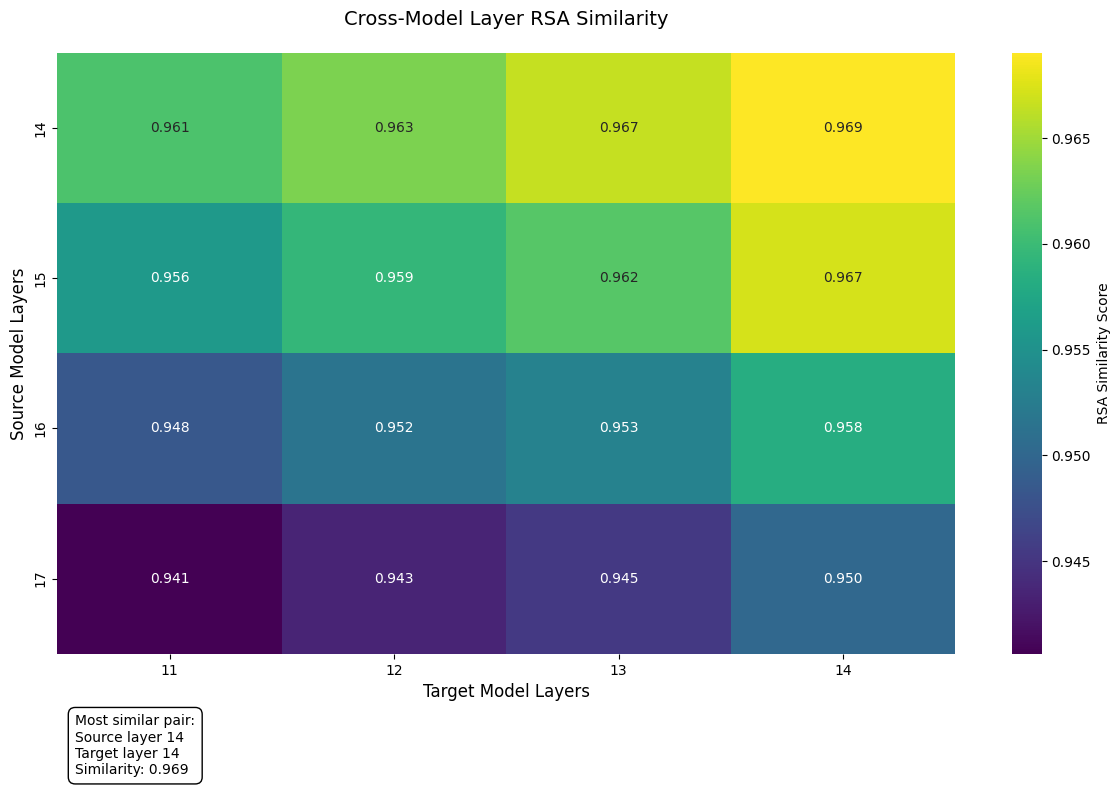


Most similar layer pair:
Source layer: 14
Target layer: 14
Similarity score: 0.969


In [ ]:
similarities = compute_all_layer_similarities(
    source_model=source_model,
    target_model=target_model,
    source_tokenizer=source_tokenizer,
    target_tokenizer= target_tokenizer,
    data_path="text_dataset.json",
    accelerator=accelerator,
    num_layers_to_compare=4,  # Number of middle layers to compare
    batch_size=8,
    max_length= 720
)